In [2]:
# 그럼 첫번째 레슨 : 라이브러리 불러오기

#필요한 딥러닝 관련 라이브러리를 불러옵니다.

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [3]:
# 🗂️ Step 2: 데이터 불러오기

#CIFAR-10 데이터셋을 불러오고, 학습용/테스트용으로 분리합니다.

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


## 과제1. 데이터의 구조를 살펴보세요. 사이즈는?

In [4]:
print("train_images shape:", train_images.shape)
print("train_labels shape:", train_labels.shape)
print("test_images shape:", test_images.shape)
print("test_labels shape:", test_labels.shape)

train_images shape: (50000, 32, 32, 3)
train_labels shape: (50000, 1)
test_images shape: (10000, 32, 32, 3)
test_labels shape: (10000, 1)


In [5]:
# 🏷️ Step 3: 클래스 이름 정의

#CIFAR-10의 라벨은 숫자로 되어 있으므로, 사람이 이해할 수 있도록 이름을 부여합니다.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 과제2. 아래 코드의 빈칸을 채워 CNN 모델을 완성해보세요. 
#### layer나 패딩 혹은 drop out, batch normalization을 추가해 가며 모델의 정확도 변화를 보는 것도 좋습니다.

In [6]:
# 🧱 Step 4: CNN 모델 구성
# Convolution → MaxPooling → Flatten → Dense 구조로 CNN을 설계합니다.
# 아래의 빈칸 (___)을 채워 모델을 완성해보세요.

model = models.Sequential()

# 첫 번째 합성곱 레이어
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # TODO: 커널 개수 설정

# 첫 번째 풀링 레이어
model.add(layers.MaxPooling2D((2, 2)))  # TODO: 풀링 크기 설정

# 두 번째 합성곱 레이어
model.add(layers.Conv2D(64, (3, 3), activation='relu'))  # TODO: 커널 크기 설정

# 두 번째 풀링 레이어
model.add(layers.MaxPooling2D((2, 2)))

# 세 번째 합성곱 레이어
model.add(layers.Conv2D(64, (3, 3), activation='relu'))  # TODO: 커널 개수 설정

# Flatten + Fully Connected Layer
model.add(layers.Flatten())
model.add(layers.Dense(64))  # TODO: 은닉층 유닛 수 설정
model.add(layers.Dense(10))  # 출력층: CIFAR-10은 클래스가 10개

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 자신이 채운 코드를 기반으로 각 레이어별 Feature Map 크기를 계산해 보세요. 
(padding은 디폴트로 없습니다.)

In [2]:
# Answer: 
import pandas as pd

# 레이어, 계산과정, Feature Map 크기 리스트 정의
layers = [
    "Input",
    "Conv2D(32, 3x3)",
    "MaxPooling2D((2, 2))",
    "Conv2D(64, 3x3)",
    "MaxPooling2D((2, 2))",
    "Conv2D(64, 3x3)",
    "Flatten",
    "Dense(64)",
    "Dense(10)"
]

calc_process = [
    "원본 이미지",
    "(32-3)+1 = 30",
    "30 // 2 = 15",
    "(15-3)+1 = 13",
    "13 // 2 = 6",
    "(6-3)+1 = 4",
    "4 x 4 x 64 = 1024",
    "",
    ""
]

feature_map_shape = [
    "(32, 32, 3)",
    "(30, 30, 32)",
    "(15, 15, 32)",
    "(13, 13, 64)",
    "(6, 6, 64)",
    "(4, 4, 64)",
    "(1024,)",
    "(64,)",
    "(10,)"
]

# DataFrame으로 정리
df = pd.DataFrame({
    "Layer": layers,
    "계산과정": calc_process,
    "Feature Map 크기": feature_map_shape
})

display(df)

,Layer,계산과정,Feature Map 크기
0,Input,원본 이미지,"(32, 32, 3)"
1,"Conv2D(32, 3x3)",(32-3)+1 = 30,"(30, 30, 32)"
2,"MaxPooling2D((2, 2))",30 // 2 = 15,"(15, 15, 32)"
3,"Conv2D(64, 3x3)",(15-3)+1 = 13,"(13, 13, 64)"
4,"MaxPooling2D((2, 2))",13 // 2 = 6,"(6, 6, 64)"
5,"Conv2D(64, 3x3)",(6-3)+1 = 4,"(4, 4, 64)"
6,Flatten,4 x 4 x 64 = 1024,"(1024,)"
7,Dense(64),,"(64,)"
8,Dense(10),,"(10,)"


In [7]:
# ⚙️ Step 5: 모델 컴파일

#모델을 학습할 수 있도록 컴파일합니다. 손실 함수, 최적화 방법, 평가지표를 설정합니다.

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 59ms/step - accuracy: 0.2575 - loss: 4.4105 - val_accuracy: 0.4087 - val_loss: 1.6117
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 65ms/step - accuracy: 0.4377 - loss: 1.5492 - val_accuracy: 0.5042 - val_loss: 1.3958
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.5117 - loss: 1.3724 - val_accuracy: 0.5441 - val_loss: 1.3039
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.5546 - loss: 1.2679 - val_accuracy: 0.5187 - val_loss: 1.4155
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - accuracy: 0.5853 - loss: 1.1754 - val_accuracy: 0.6050 - val_loss: 1.1296
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.6224 - loss: 1.0781 - val_accuracy: 0.6054 - val_loss: 1.1272
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6492 - loss: 1.0124 - val_accuracy: 0.6132 - val_loss: 1.1187
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - accuracy: 0.666

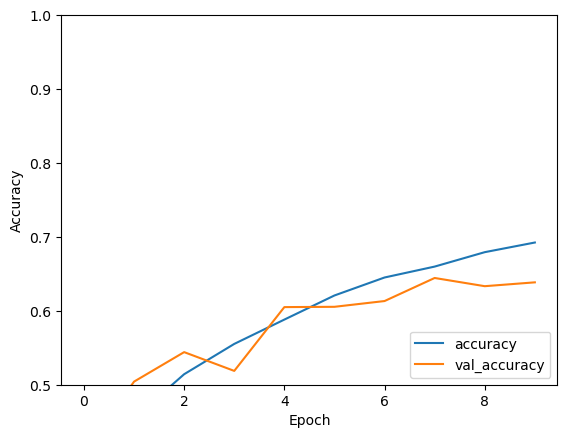

In [8]:
# 🔥 Step 6: 모델 학습 및 성능 평가

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))
#모델 성능 평가
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,
                                     test_labels,
                                     verbose=2)

In [10]:
print('Test Accuracy is',test_acc)

Test Accuracy is 0.6384999752044678


## 과제3. 직접사용해 보기. 이미지를 로드하고 cifar-10의 사이즈로 리사이즈

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step


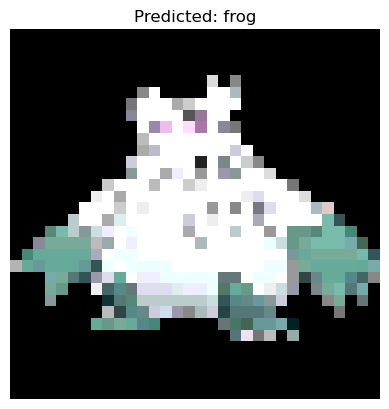

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 새 이미지를 로드하고 모델 예측 수행
def predict_new_image(image_path, model, class_names):
    # 이미지 로드 및 전처리
    img = image.load_img(image_path, target_size=(32, 32))  # CIFAR-10 크기로 리사이즈 빈칸채우기
    img_array = image.img_to_array(img)  # 이미지를 배열로 변환
    img_array = np.expand_dims(img_array, axis=0)  # 배치를 위해 차원 추가
    img_array = img_array / 255.0  # 정규화 

    # 예측 수행
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)  # 가장 높은 확률의 클래스 인덱스
    class_name = class_names[predicted_class]  # 클래스 이름

    # 결과 출력
    plt.imshow(img)
    plt.title(f"Predicted: {class_name}")
    plt.axis('off')
    plt.show()

# 사용 예시
image_path = "abomasnow.png"
predict_new_image(image_path, model, class_names)

## 왜 255.0으로 나누었을까요? 이미지 전처리에 대한 지식이니 조사해보세요.

# Answer 

디지털 이미지는 각 픽셀의 값이 0, 255 사이의 정수로 저장되어 있다. 하지만 신경망은 보통 입력값의 범위가 0에서 1처럼 작고 일정한 값일 때 더 잘 학습된다. 이미지 픽셀값이 그대로 0,255면 가중치와 곱해질 때 값이 너무 커져서 학습이 불안정해지고 오버플로우 등 문제가 생길 수 있다. 그래서 255으로 나누어 모든 픽셀 값을 0과 1사이의 범위로 정규화해준다.

## 과제4. CNN의 inductive bias에 대해서 조사를 해보고 생각해 봅시다.
### CNN은 왜 이미지 처리에 좋을까요? 이미지 말고도 CNN을 잘 쓸 수 있는데는 어디일까요?

# Answer

CNN의 Inductive Bias는 모델이 학습 데이터에서 관찰하지 않은 데이터에 대해서도  잘 일반화할 수 있게 해주는 모델 구조의 기본적인 가정이나 성질을 의미.

CNN이 이미지 처리에 강한이유는 합성곱 레이어에서 이미지 내에서 국소적인 패턴(모서리, 선, 점 등)을 효과적으로 잡아내고
여러 레이어를 거치며 점점 더 복잡하고 추상적인 특징까지 인식하기 때문.

CNN은 본래 이미지 처리를 위해 고안됐지만 근접한 데이터끼리 관계가 있다는 특성을 활용할 수 있는 다양한 분야에서 강점을 보인다.
시계열 데이터 (주가 차트, 센서 데이터): 시간의 흐름에 따라 인접 값들이 연관이 있는 경우 1D-CNN으로 분석 가능
오디오 신호 (음성 인식, 음악 장르 분류, 환경 소리 탐지): 오디오 신호나 이미지처럼 변환된 데이터에 적용
텍스트 데이터(감정 분석, 키워드 추출, 문장 분류): 텍스트를 단어 시퀀스로 바꿔 1D-CNN을 사용